# Fase 1 — Setup e Exploração do Corpus FakeRecogna

**Dataset:** FakeRecogna (GARCIA; AFONSO; PAPA, 2022) — 11.902 notícias em português, balanceadas entre falsas e verdadeiras, com metadados de categoria, data, autor e URL.

Estrutura do projeto: `notebooks/` (este arquivo) · `dados/` · `figuras/`.

In [21]:
%pip install datasets pandas matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("recogna-nlp/FakeRecogna")
df = dataset["train"].to_pandas()
print(f"{df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

11903 linhas x 8 colunas


,Titulo,Subtitulo,Noticia,Categoria,Data,Autor,URL,Classe
0,\n\nPapa Francisco foi preso sob acusação de t...,Boato – Ocorreu um apagão no Vaticano. O papa ...,apagão vaticano papar presar acusação tráfico ...,entretenimento,11/01/2021,\nEdgard Matsuki,https://www.boatos.org/religiao/papa-francisco...,0.0
1,Equador prepara cova coletiva para mortos por ...,None,o governar equador anunciar preparar cova cole...,saúde,27/03/2020 18h25,27/03/2020 18h25,https://noticias.uol.com.br/internacional/ulti...,1.0
2,Air France voltará a operar voo direto Pequim-...,None,o companhia air france operar voar direto pequ...,saúde,07/08/2020 13h42,07/08/2020 13h42,https://www.uol.com.br/nossa/noticias/afp/2020...,1.0
3,Marfrig intensifica venda de carne do Brasil a...,None,o marfrig global foods retomar vender carnar b...,saúde,27/04/2020 14h53,27/04/2020 14h53,https://economia.uol.com.br/noticias/reuters/2...,1.0
4,As parciais das eleições de 2014 alternaram ma...,None,o assunto voltar o compartilhar rede social ju...,entretenimento,31/07/2021,Gilmar Lopes,https://www.e-farsas.com/as-parciais-das-eleic...,0.0


*Alternativa, caso `load_dataset` falhe por proxy/rede:*

In [23]:
# url = "https://huggingface.co/datasets/recogna-nlp/FakeRecogna/resolve/refs%2Fconvert%2Fparquet/default/train/0000.parquet"
# df = pd.read_parquet(url)

In [24]:
import matplotlib as mpl
import matplotlib.pyplot as plt

CORAL = "#D30D3B"   # Fake
AZUL = "#248FB3"    # Real

mpl.rcParams.update({
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": "#073B4C",
    "axes.labelsize": 10.5,
    "axes.labelweight": "bold",
    "axes.edgecolor": "#999999",
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#E6E6E6",
    "grid.linewidth": 0.7,
    "legend.frameon": False,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

## Inspeção estrutural e valores ausentes

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11903 entries, 0 to 11902
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Titulo     11872 non-null  object 
 1   Subtitulo  5580 non-null   object 
 2   Noticia    11902 non-null  object 
 3   Categoria  11902 non-null  object 
 4   Data       11551 non-null  object 
 5   Autor      11886 non-null  object 
 6   URL        11902 non-null  object 
 7   Classe     11902 non-null  float64
dtypes: float64(1), object(7)
memory usage: 744.1+ KB


In [26]:
ausentes = df.isnull().sum()
pd.DataFrame({"ausentes": ausentes, "%": (ausentes / len(df) * 100).round(2)}).sort_values("ausentes", ascending=False)

,ausentes,%
Subtitulo,6323,53.12
Data,352,2.96
Titulo,31,0.26
Autor,17,0.14
Categoria,1,0.01
Noticia,1,0.01
URL,1,0.01
Classe,1,0.01


Apenas 1 registro tem valores ausentes nos campos essenciais (texto, classe, categoria, URL) — será removido na Fase 2.

## Balanceamento da variável-alvo

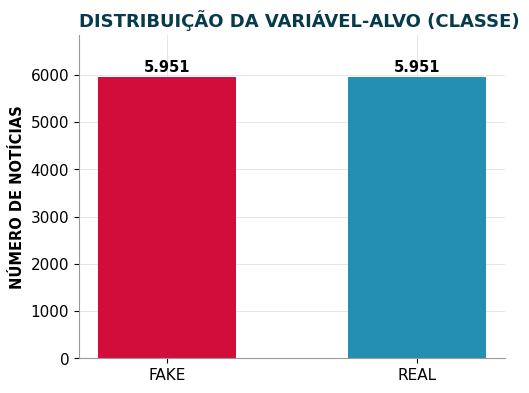

In [27]:
contagem_classe = df["Classe"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5.5, 4.2))
barras = ax.bar(["FAKE", "REAL"], contagem_classe.values, color=[CORAL, AZUL], width=0.55)
for barra in barras:
    altura = barra.get_height()
    ax.annotate(f"{altura:,}".replace(",", "."), xy=(barra.get_x() + barra.get_width()/2, altura),
                xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10.5, fontweight="bold")
ax.set_ylabel("NÚMERO DE NOTÍCIAS")
ax.set_title("DISTRIBUIÇÃO DA VARIÁVEL-ALVO (CLASSE)", loc="left")
ax.set_ylim(0, max(contagem_classe.values) * 1.15)
plt.savefig("../figuras/balanceamento_classe.png")
plt.show()

## Distribuição por categoria

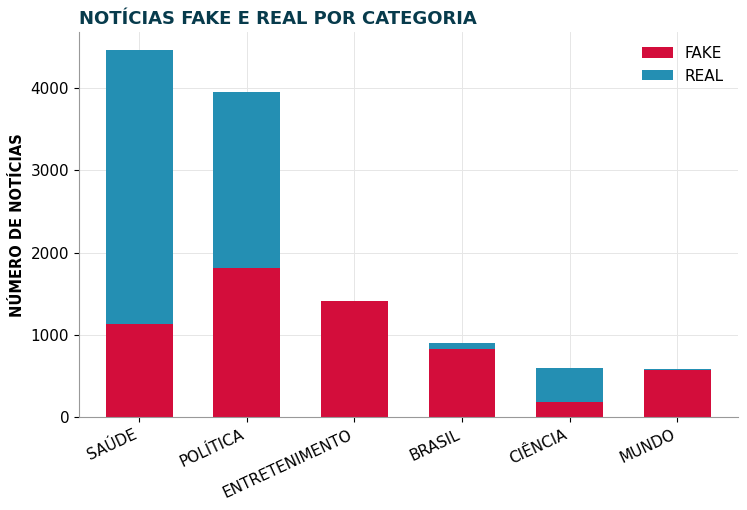

In [28]:
tabela = pd.crosstab(df["Categoria"], df["Classe"]).rename(columns={0: "FAKE", 1: "REAL"})
tabela["Total"] = tabela.sum(axis=1)
tabela = tabela.sort_values("Total", ascending=False)
tabela.index = [c.upper() for c in tabela.index]

fig, ax = plt.subplots(figsize=(8.5, 5))
tabela[["FAKE", "REAL"]].plot(kind="bar", stacked=True, ax=ax, color=[CORAL, AZUL], width=0.62)
ax.set_title("NOTÍCIAS FAKE E REAL POR CATEGORIA", loc="left")
ax.set_ylabel("NÚMERO DE NOTÍCIAS")
ax.set_xlabel("")
plt.xticks(rotation=25, ha="right")
ax.legend(title=None)
plt.savefig("../figuras/categoria_vs_classe.png")
plt.show()

## Tamanho do texto por classe

         count        mean        std  min   25%   50%    75%     max
Classe                                                               
0.0     5951.0   68.551168  54.302842  1.0  35.0  61.0   85.0  1233.0
1.0     5951.0  101.896992  73.318375  1.0  70.0  89.0  113.0  1698.0


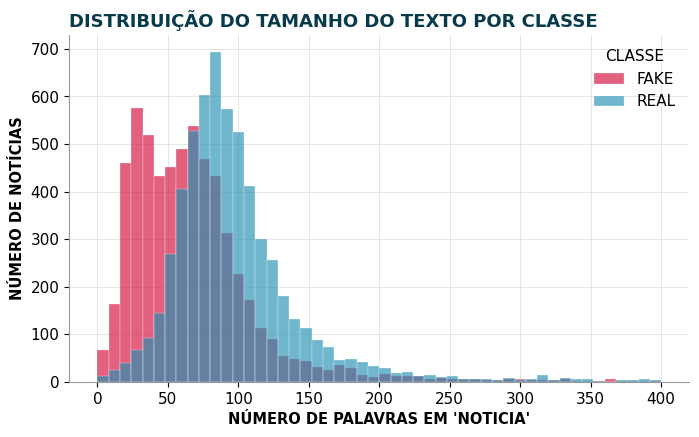

In [29]:
df["n_palavras_noticia"] = df["Noticia"].str.split().str.len()
print(df.groupby("Classe")["n_palavras_noticia"].describe())

fig, ax = plt.subplots(figsize=(8, 4.5))
for classe, cor, rotulo in [(0, CORAL, "FAKE"), (1, AZUL, "REAL")]:
    dados = df.loc[df["Classe"] == classe, "n_palavras_noticia"]
    ax.hist(dados, bins=50, range=(0, 400), alpha=0.65, color=cor, label=rotulo, edgecolor="white", linewidth=0.3)
ax.set_title("DISTRIBUIÇÃO DO TAMANHO DO TEXTO POR CLASSE", loc="left")
ax.set_xlabel("NÚMERO DE PALAVRAS EM 'NOTICIA'")
ax.set_ylabel("NÚMERO DE NOTÍCIAS")
ax.legend(title="CLASSE")
plt.savefig("../figuras/tamanho_texto_por_classe.png")
plt.show()

**Achado relevante:** notícias reais são sistematicamente mais longas que as falsas — viés de artefato (*shortcut learning*, GEIRHOS et al., 2020; HAROON et al., 2026) discutido no artigo como limitação metodológica.

## Checkpoint

In [30]:
df.to_csv("../dados/fakerecogna_bruto.csv", index=False)
print("Checkpoint salvo em ../dados/fakerecogna_bruto.csv")

Checkpoint salvo em ../dados/fakerecogna_bruto.csv
